In [1]:
print("Everything is okay")

Everything is okay


#### Build a simple workflow or graph using langgraph

##### State

- First, define the state of the graph.
- The State schema serves as input schema for all Nodes and Edges in the Graph.
- Let's use TypedDict class from Puython's typing module as our schema, which provides the type hints for the keys.

For defining state schema - TypedDict

In Python, TypedDict is a type hint utility from the typing module that allows you to specify a fixed schema for dictionaries, mapping expected string keys to specific value types.

In [20]:
# Build a simple workflow or graph using langgraph
# Create a state class

from typing_extensions import TypedDict

class State(TypedDict):
    graph_info:str   

In [21]:
State

__main__.State

In [4]:
State()

{}

#### Nodes

- Nodes are just a python fucntions. 
- In LangGraph, a node is a Python function (or any LangChain Runnable) that represents a discrete step, action, or logic block within an AI agent's workflow. 
- Nodes are the "workers" of the graph, responsible for doing the work—such as processing user input, calling an LLM, querying a database, or performing a tool call. 
- In Node, the first positional aregument is the state as defined above. Because the node carry the agent's progress or state or information.
- Beacuse the state is the typedDict with schema as define above, each node can access the key, graph_state with state['graph_state] 
- Each node returns a new value of the state key graph_state.
- By default the new value returned by each node will override the prior state value.

In [22]:
def start_read(state:State):
    print("start_read node has been called")
    return {"graph_info": state["graph_info"]+"I am planning to start reading. "}

In [23]:
def machine_learning(state:State):
    print("machine_learning node has been called")
    return {"graph_info": state["graph_info"]+"I am going to read machine learning. "}

def generative_ai(state:State):
    print("generative_ai node has been called")
    return {"graph_info": state["graph_info"]+"I am going to read generative ai. "}

In [24]:
# Define the edge function to choose between machine_learning and generative_ai
# The function randomly selects one of the two courses
# Literal is used when a parameter can only have specific literal values.

import random
from typing import Literal

def random_course_choice(state:State) -> Literal["machine_learning", "generative_ai"]:
    graph_info = state["graph_info"]
    
    if random.random() > 0.5:
        choice = "generative_ai"
        return choice
    else:
        choice = "machine_learning"
        return choice

In [17]:
random_course_choice

<function __main__.random_course_choice(state: __main__.State) -> Literal['machine_learning', 'generative_ai']>

In [25]:
random_course_choice()

TypeError: random_course_choice() missing 1 required positional argument: 'state'

### Graph Construction

- Now, we build the graph from our components defined above.
- The StateGraph class is the graph class the we can use.
- First, we initialize a StateGraph with the state class we defined above.
- Then we add our nodes and edges.
- We use the START Node, a special node that sends user input to the graph, to indiacte where to start our graph.
- The END Nodeis a special node that represents a termonal node.
- Finally we compile our graph to perform a few basic checks on the graph structure.
- We can visualize the graph as a Mermaid diagram.

In [26]:
# Library for creating graph of the defined nodes and edges or basically the workflow
# StateGraph from langgraph to create the graph - A graph whose nodes communicate by reading and writing to a shared state.

# In AI engineering (specifically the LangGraph library), a StateGraph is a builder class used to create cyclical, stateful AI workflows. It manages a shared state—a data payload that passes between different steps—allowing multiple Large Language Model (LLM) agents and tools to communicate, collaborate, and make decisions dynamically.

# LLM Agent orchestration class

from langgraph.graph import StateGraph, START, END

In [27]:
# Initialize the StateGraph Class
graph = StateGraph(State)

# Add nodes to the graph
graph.add_node("start_read", start_read)
graph.add_node("machine_learning", machine_learning)
graph.add_node("generative_ai", generative_ai)

# Add edges to the graph - schedule the flow of execution
graph.add_edge(START, "start_read")
graph.add_conditional_edges("start_read", random_course_choice)
graph.add_edge("machine_learning", END)
graph.add_edge("generative_ai", END)

# Compile the graph to prepare it for execution
graph_workflow = graph.compile()

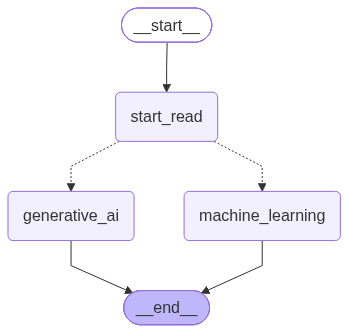

In [12]:
from IPython.display import Image, display

display(Image(graph_workflow.get_graph().draw_mermaid_png()))

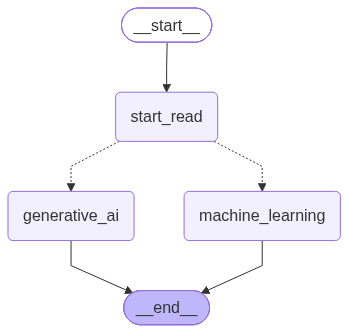

In [13]:
graph_workflow

In [33]:
# Invoke the graph
graph_workflow.invoke({"graph_info": "Hello, how are you?, Mr. Anant ?"})

start_read node has been called
machine_learning node has been called


{'graph_info': 'Hello, how are you?, Mr. Anant ?I am planning to start reading. I am going to read machine learning. '}

In [35]:
print(graph_workflow.get_graph().draw_ascii())

                 +-----------+                    
                 | __start__ |                    
                 +-----------+                    
                       *                          
                       *                          
                       *                          
                +------------+                    
                | start_read |                    
                +------------+                    
               ...            ...                 
             ..                  ..               
           ..                      ..             
+---------------+           +------------------+  
| generative_ai |           | machine_learning |  
+---------------+           +------------------+  
               ***            ***                 
                  **        **                    
                    **    **                      
                  +---------+                     
                  | __end__ |  